# Plot Flux Rope Tutorial 
> Read VTK files and Plot Magnetic Field Lines

What you will learn:
1. How to read a series of Athena VTK files?
2. How to derive dependent variables (e.g., jz)?
3. How to plot a 2D field and overlay magnetic field lines using `Az` contours?

In [1]:
# Prepare runtime dependencies for this notebook
import importlib
import subprocess
import sys

def ensure_package(pkg_name: str):
    try:
        importlib.import_module(pkg_name)
        print(f'{pkg_name}: already installed')
    except ModuleNotFoundError:
        print(f'{pkg_name}: not found, installing...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])
        print(f'{pkg_name}: installed')

for pkg in ('vtk', 'joblib'):
    ensure_package(pkg)

vtk: already installed
joblib: already installed


In [2]:
from pathlib import Path
import glob
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make plots visible in notebook
%matplotlib inline

# Add custom reader module path
repo_root = Path('./')
candidate_paths = [repo_root]
for p in candidate_paths:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import athena_vtk_reader


In [3]:
# User settings
vtk_dir = Path('./run_case_01')
frame_index = 0    # choose which vtk file to display

In [4]:
# Get the file list
def list_vtk_files(vtk_folder: Path):
    files = sorted(glob.glob(str(vtk_folder / '*.vtk')))
    if len(files) == 0:
        raise FileNotFoundError(f'No VTK files found in: {vtk_folder}')
    return files

# Az
def az_calc(bx, by, x, y):
    nx = len(x)
    ny = len(y)
    a = np.zeros((ny, nx))
    a[ny-1,nx-1] = 0.0
    
    # find the location where |By| is minimal at the bottom boundary
    bybottom = by[0, :]
    ixc = np.argmin(np.abs(bybottom))
    a[0, ixc] = 0.0
    
    for j in range(1, ny):
        a[j, ixc] = a[j-1, ixc] - 0.5*(bx[j, ixc]+bx[j-1, ixc])*(y[j]-y[j-1])
    
    for my in range(1, ny):
        ky = ny-1-my
        a[ky, nx-1] = (a[ky+1, nx-1]
                         + 0.5*(bx[ky, nx-1]+bx[ky+1, nx-1])*(y[ky]-y[ky+1]))
    for my in range(0, ny):
        ky = ny-1-my
        for mx in range(0, nx-1):
            kx = nx-1-mx
            a[ky, kx-1] = (a[ky, kx]
                             - 0.5*(by[ky,kx]+by[ky,kx-1])*(x[kx-1]-x[kx]))
    return a

# Jz
def jz_calc(bx, by, x, y):
    nx = len(x)
    ny = len(y)
    jz = np.zeros((ny, nx))

    # Need at least a few points for centered stencils
    if nx < 5 or ny < 5:
        return jz

    dx = np.fabs(x[1] - x[0])
    dy = np.fabs(y[1] - y[0])

    # Interior: 4th-order centered finite difference
    for i in range(2, nx - 2):
        for j in range(2, ny - 2):
            pbypx = (1.0 / 12.0) * (-by[j, i + 2] + 8.0 * by[j, i + 1] - 8.0 * by[j, i - 1] + by[j, i - 2]) / dx
            pbxpy = (1.0 / 12.0) * (-bx[j + 2, i] + 8.0 * bx[j + 1, i] - 8.0 * bx[j - 1, i] + bx[j - 2, i]) / dy
            jz[j, i] = pbypx - pbxpy

    # Near top/bottom boundaries: 2nd-order centered difference
    j = 1
    for i in range(1, nx - 1):
        pbypx = (by[j, i + 1] - by[j, i - 1]) / (x[i + 1] - x[i - 1])
        pbxpy = (bx[j + 1, i] - bx[j - 1, i]) / (y[j + 1] - y[j - 1])
        jz[j, i] = pbypx - pbxpy

    j = ny - 2
    for i in range(1, nx - 1):
        pbypx = (by[j, i + 1] - by[j, i - 1]) / (x[i + 1] - x[i - 1])
        pbxpy = (bx[j + 1, i] - bx[j - 1, i]) / (y[j + 1] - y[j - 1])
        jz[j, i] = pbypx - pbxpy

    for i in range(nx):
        jz[0, i] = jz[1, i]
        jz[ny - 1, i] = jz[ny - 2, i]

    # Near left/right boundaries: 2nd-order centered difference
    i = 1
    for j in range(1, ny - 1):
        pbypx = (by[j, i + 1] - by[j, i - 1]) / (x[i + 1] - x[i - 1])
        pbxpy = (bx[j + 1, i] - bx[j - 1, i]) / (y[j + 1] - y[j - 1])
        jz[j, i] = pbypx - pbxpy

    i = nx - 2
    for j in range(1, ny - 1):
        pbypx = (by[j, i + 1] - by[j, i - 1]) / (x[i + 1] - x[i - 1])
        pbxpy = (bx[j + 1, i] - bx[j - 1, i]) / (y[j + 1] - y[j - 1])
        jz[j, i] = pbypx - pbxpy

    for j in range(ny):
        jz[j, 0] = jz[j, 1]
        jz[j, nx - 1] = jz[j, nx - 2]

    return jz


In [5]:
files = list_vtk_files(vtk_dir)
print(f'Found {len(files)} VTK files')

frame_index = min(frame_index, len(files) - 1)
filename = files[frame_index]
print('Reading:', filename)

data = athena_vtk_reader.read(filename)

x = np.asarray(data['x'])
y = np.asarray(data['y'])
bx = data['bx'][0,:,:] # 3D to 2D 
by = data['by'][0,:,:]
bz = data['bz'][0,:,:]
time = data['time']

# Compute Az (the magnetic vector potential) for magnetic field-line plotting.
az = az_calc(bx, by, x, y)

# Optional: also compute Jz for diagnostics/checks.
jz = jz_calc(bx, by, x, y)

Found 11 VTK files
Reading: run_case_01/fluxrope.0000.vtk
 Time =  0.0


 Time =  0.0


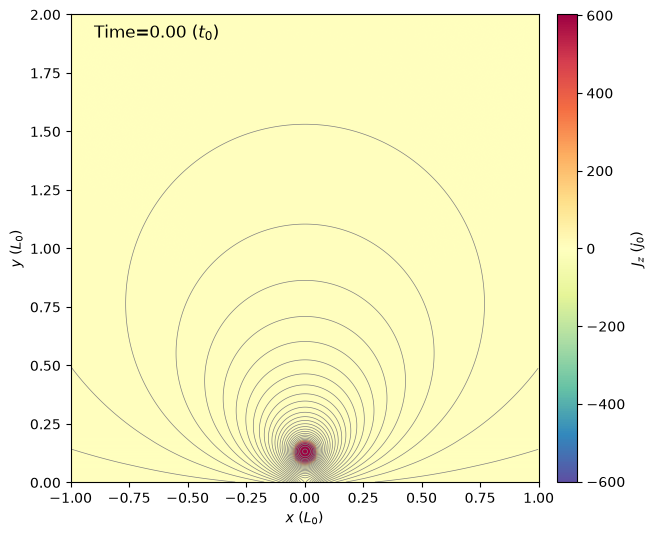

In [6]:
def plot_frame(filename, output_path=None, show=False):
    # Read one VTK frame and convert the magnetic field to 2D.
    data = athena_vtk_reader.read(str(filename))
    x = np.asarray(data['x'])
    y = np.asarray(data['y'])
    bx = data['bx'][0, :, :]
    by = data['by'][0, :, :]
    time = data['time']

    az = az_calc(bx, by, x, y)
    jz = jz_calc(bx, by, x, y)

    # Fixed axes positions keep long colorbar tick labels from moving the plot.
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_axes([0.10, 0.12, 0.72, 0.78])
    cax = fig.add_axes([0.775, 0.12, 0.025, 0.78])
    ax.text(0.05, 0.95, r'Time={0:.2f} ($t_{{0}}$)'.format(time),
            transform=ax.transAxes, fontsize=12)
    ax.set_xlabel(r'$x$ ($L_0$)')
    ax.set_ylabel(r'$y$ ($L_0$)')
    ax.set_aspect('equal', 'box')

    scale = np.amax(np.fabs(jz))
    if not np.isfinite(scale) or scale == 0.0:
        scale = 1.0e-12

    img = ax.pcolormesh(x, y, jz, cmap='Spectral_r',
                        vmin=-scale, vmax=scale, shading='auto')
    ax.contour(x, y, az, 30, colors='gray',
               linestyles='solid', linewidths=0.5)

    cbar = fig.colorbar(img, cax=cax)
    cbar.set_label(r'$J_{z}$ ($j_0$)')

    if output_path is not None:
        output_path = Path(output_path)
        fig.savefig(output_path, dpi=200)
    if show:
        plt.show()
    plt.close(fig)

    return str(output_path) if output_path is not None else None

# Preview the selected frame with the same function used for batch export.
plot_frame(filename, show=True)

In [7]:
# Export all frames in parallel using separate worker processes.
import os
import shutil
joblib = importlib.import_module('joblib')

output_dir = vtk_dir / 'demo_plots'
output_dir.mkdir(parents=True, exist_ok=True)

# Limit the process count
n_jobs = max(1, min(4, (os.cpu_count() or 2) - 1))
frame_jobs = [
    (vtk_file, output_dir / 'frame_{0:04d}.png'.format(index))
    for index, vtk_file in enumerate(files)
]

output_files = joblib.Parallel(n_jobs=n_jobs, backend='loky', verbose=0)(
    joblib.delayed(plot_frame)(vtk_file, output_path, show=False)
    for vtk_file, output_path in frame_jobs
)
print('Exported {0} frames to: {1}'.format(len(output_files), output_dir))

# Convert the numbered PNG sequence to an MPEG-4 movie.
ffmpeg_path = shutil.which('ffmpeg')
if ffmpeg_path is None:
    raise RuntimeError('ffmpeg was not found. Install it with: brew install ffmpeg')

frame_rate = 10
movie_file = output_dir / 'jz_movie.mp4'
ffmpeg_command = [
    ffmpeg_path,
    '-y',
    '-loglevel', 'error',
    '-framerate', str(frame_rate),
    '-start_number', '0',
    '-i', str(output_dir / 'frame_%04d.png'),
    '-c:v', 'libx264',
    '-pix_fmt', 'yuv420p',
    '-movflags', '+faststart',
    str(movie_file),
]
subprocess.run(ffmpeg_command, check=True)
print('Movie saved to: {0}'.format(movie_file))

Exported 11 frames to: run_case_01/demo_plots
Movie saved to: run_case_01/demo_plots/jz_movie.mp4
 Time =  0.1000405
 Time =  0.6001412
 Time =  0.200084
 Time =  0.5000687
 Time =  1.0
 Time =  0.0
 Time =  0.7001229
 Time =  0.9000202
 Time =  0.3000741
 Time =  0.4001788
 Time =  0.8000217
